# Data Dragons

## Import Libraries

In [122]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)

In [123]:
data_path = Path("Data Files")
subset_path = Path("Random subset of data files")

variable_list = pd.read_csv(Path("Documentation/variable_list.csv"),encoding='latin-1')
codebook = pd.read_csv(Path('Documentation/codebook.csv'))

In [124]:
# page_views_df = pd.read_csv(Path(subset_path,'page_views.csv'))
# responses_df = pd.read_csv(Path(subset_path,'responses.csv'))
# items_df = pd.read_csv(Path(subset_path,'items.csv'))
# media_views_df = pd.read_csv(Path(subset_path, 'media_views.csv'))
# checkpoints_df = pd.read_csv(Path(subset_path, 'checkpoints.csv'))

In [125]:
page_views_df = pd.read_csv(Path(data_path,'page_views.csv'))
responses_df = pd.read_csv(Path(data_path,'responses.csv'))
items_df = pd.read_csv(Path(data_path,'items.csv'))
media_views_df = pd.read_csv(Path(data_path,'media_views.csv'))
checkpoints_df = pd.read_csv(Path(data_path,'checkpoints.csv'))

/var/folders/rb/yl_gwgt51rggw0ydvv3ksqnh0000gn/T/ipykernel_12875/2383540840.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  page_views_df = pd.read_csv(Path(data_path,'page_views.csv'))
/var/folders/rb/yl_gwgt51rggw0ydvv3ksqnh0000gn/T/ipykernel_12875/2383540840.py:2: DtypeWarning: Columns (32,33,34,35,36,37,38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  responses_df = pd.read_csv(Path(data_path,'responses.csv'))


## Data

items, media views, page views, responses, checkpoints datasets

The labels ABC or ABCD refer to the content included in the books

Section A refers to the first 4 chapters of the book that include an introduction to R and making data visualizations

Section B refers to the next 5 chapters which focus on modeling variation with simple models (goes up through models that include one predictor variable, e.g., regression and grouping models)

Section C refers to 3 chapters that cover inferential statistics with a modeling approach (hypothesis testing and confidence intervals with and without simulations)

Section D refers to 4 chapters that cover multivariate models (factorial ANOVA, ANCOVA, and multiple regression).

### Learning Items

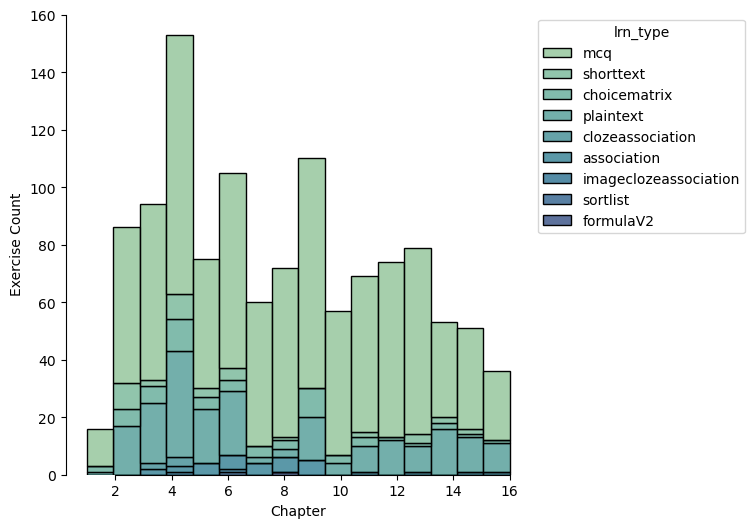

In [126]:
fig, ax = plt.subplots(figsize=(6,6))

g = sns.histplot(data=items_df, 
                 x="chapter_number", 
                 hue="lrn_type", 
                 bins=16, 
                 multiple="stack",
                 palette="crest")

g.set(xlabel="Chapter", ylabel='Exercise Count')

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

sns.despine(trim=True)

plt.show()

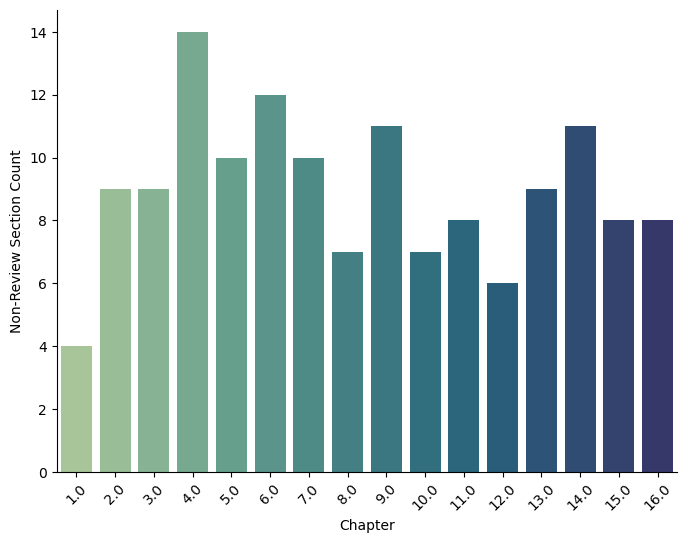

In [127]:
non_review = page_views_df[['chapter_number','section_number','review_flag']].drop_duplicates(subset=['chapter_number','section_number'])
non_review = non_review[non_review['review_flag'] == False]

plt.figure(figsize=(8,6))

ax = sns.countplot(data=non_review,
              x="chapter_number",
              hue="chapter_number",
              palette="crest")

ax.legend_.remove()

plt.xlabel("Chapter")
plt.ylabel("Non-Review Section Count")

sns.despine()

plt.xticks(rotation=45)

plt.show()

## Analysis

aggregated data about particular sections pages in the textbook, most granular (chapter + section)

In [128]:
page_views_df = page_views_df[page_views_df['engaged'] >= 0]

In [129]:
# page aggregate dataframe
page_views_summary_df = (
    page_views_df.groupby(['student_id', 'chapter_number', 'section_number', 'was_complete', 'review_flag'], as_index=False)
    .agg(
        {
            'engaged': 'sum',
            'idle_brief': 'sum',
            'idle_long': 'sum',
            'off_page_brief': 'sum',
            'off_page_long': 'sum',
        }
    )
)

# calculate total time spent on page
page_views_summary_df['page_total_time'] = (
    page_views_summary_df['engaged']
    + page_views_summary_df['idle_brief']
    + page_views_summary_df['idle_long']
    + page_views_summary_df['off_page_brief']
    + page_views_summary_df['off_page_long']
)

# drop unengagement columns
page_views_summary_df.drop(labels=['idle_brief', 'idle_long', 'off_page_brief', 'off_page_long'], axis=1, inplace=True)

# calculate page engagement ratio
page_views_summary_df['page_engagement_ratio'] = page_views_summary_df['engaged'] / page_views_summary_df['page_total_time']

# drop rows where page_engagement ratio = nan, implies no time spent on page
page_views_summary_df = page_views_summary_df.dropna(subset=['page_engagement_ratio'])

In [130]:
# make column encoding chapter.section
page_views_summary_df['chapter_number'] = page_views_summary_df['chapter_number'].astype(int)
page_views_summary_df['section_number'] = page_views_summary_df['section_number'].astype(int)

page_views_summary_df['chapter_section'] = page_views_summary_df['chapter_number'].astype(str) + '.' + page_views_summary_df['section_number'].astype(str)
page_views_summary_df['chapter_section'] = page_views_summary_df['chapter_section'].astype(float)

In [131]:
#log transforms log(1+x) and log(x) when appropriate
page_views_summary_df['engaged_log1p'] = np.log1p(page_views_summary_df["engaged"]) #log(1+x) b/c possibility of no engagement with text
page_views_summary_df['page_total_log'] = np.log(page_views_summary_df["page_total_time"])

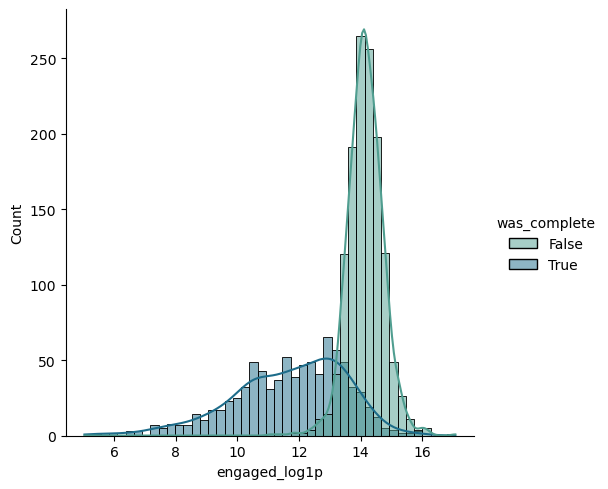

In [132]:
sns.displot(data=page_views_summary_df[page_views_summary_df['chapter_section'] == 2.4], x='engaged_log1p', kde=True, hue='was_complete', palette='crest')
plt.show()

engagement time and total time get closer to normal distribution after transformation, ratio is closer to bimodal probably b/c of disparity between students that don't engage critically and students who do engage critically

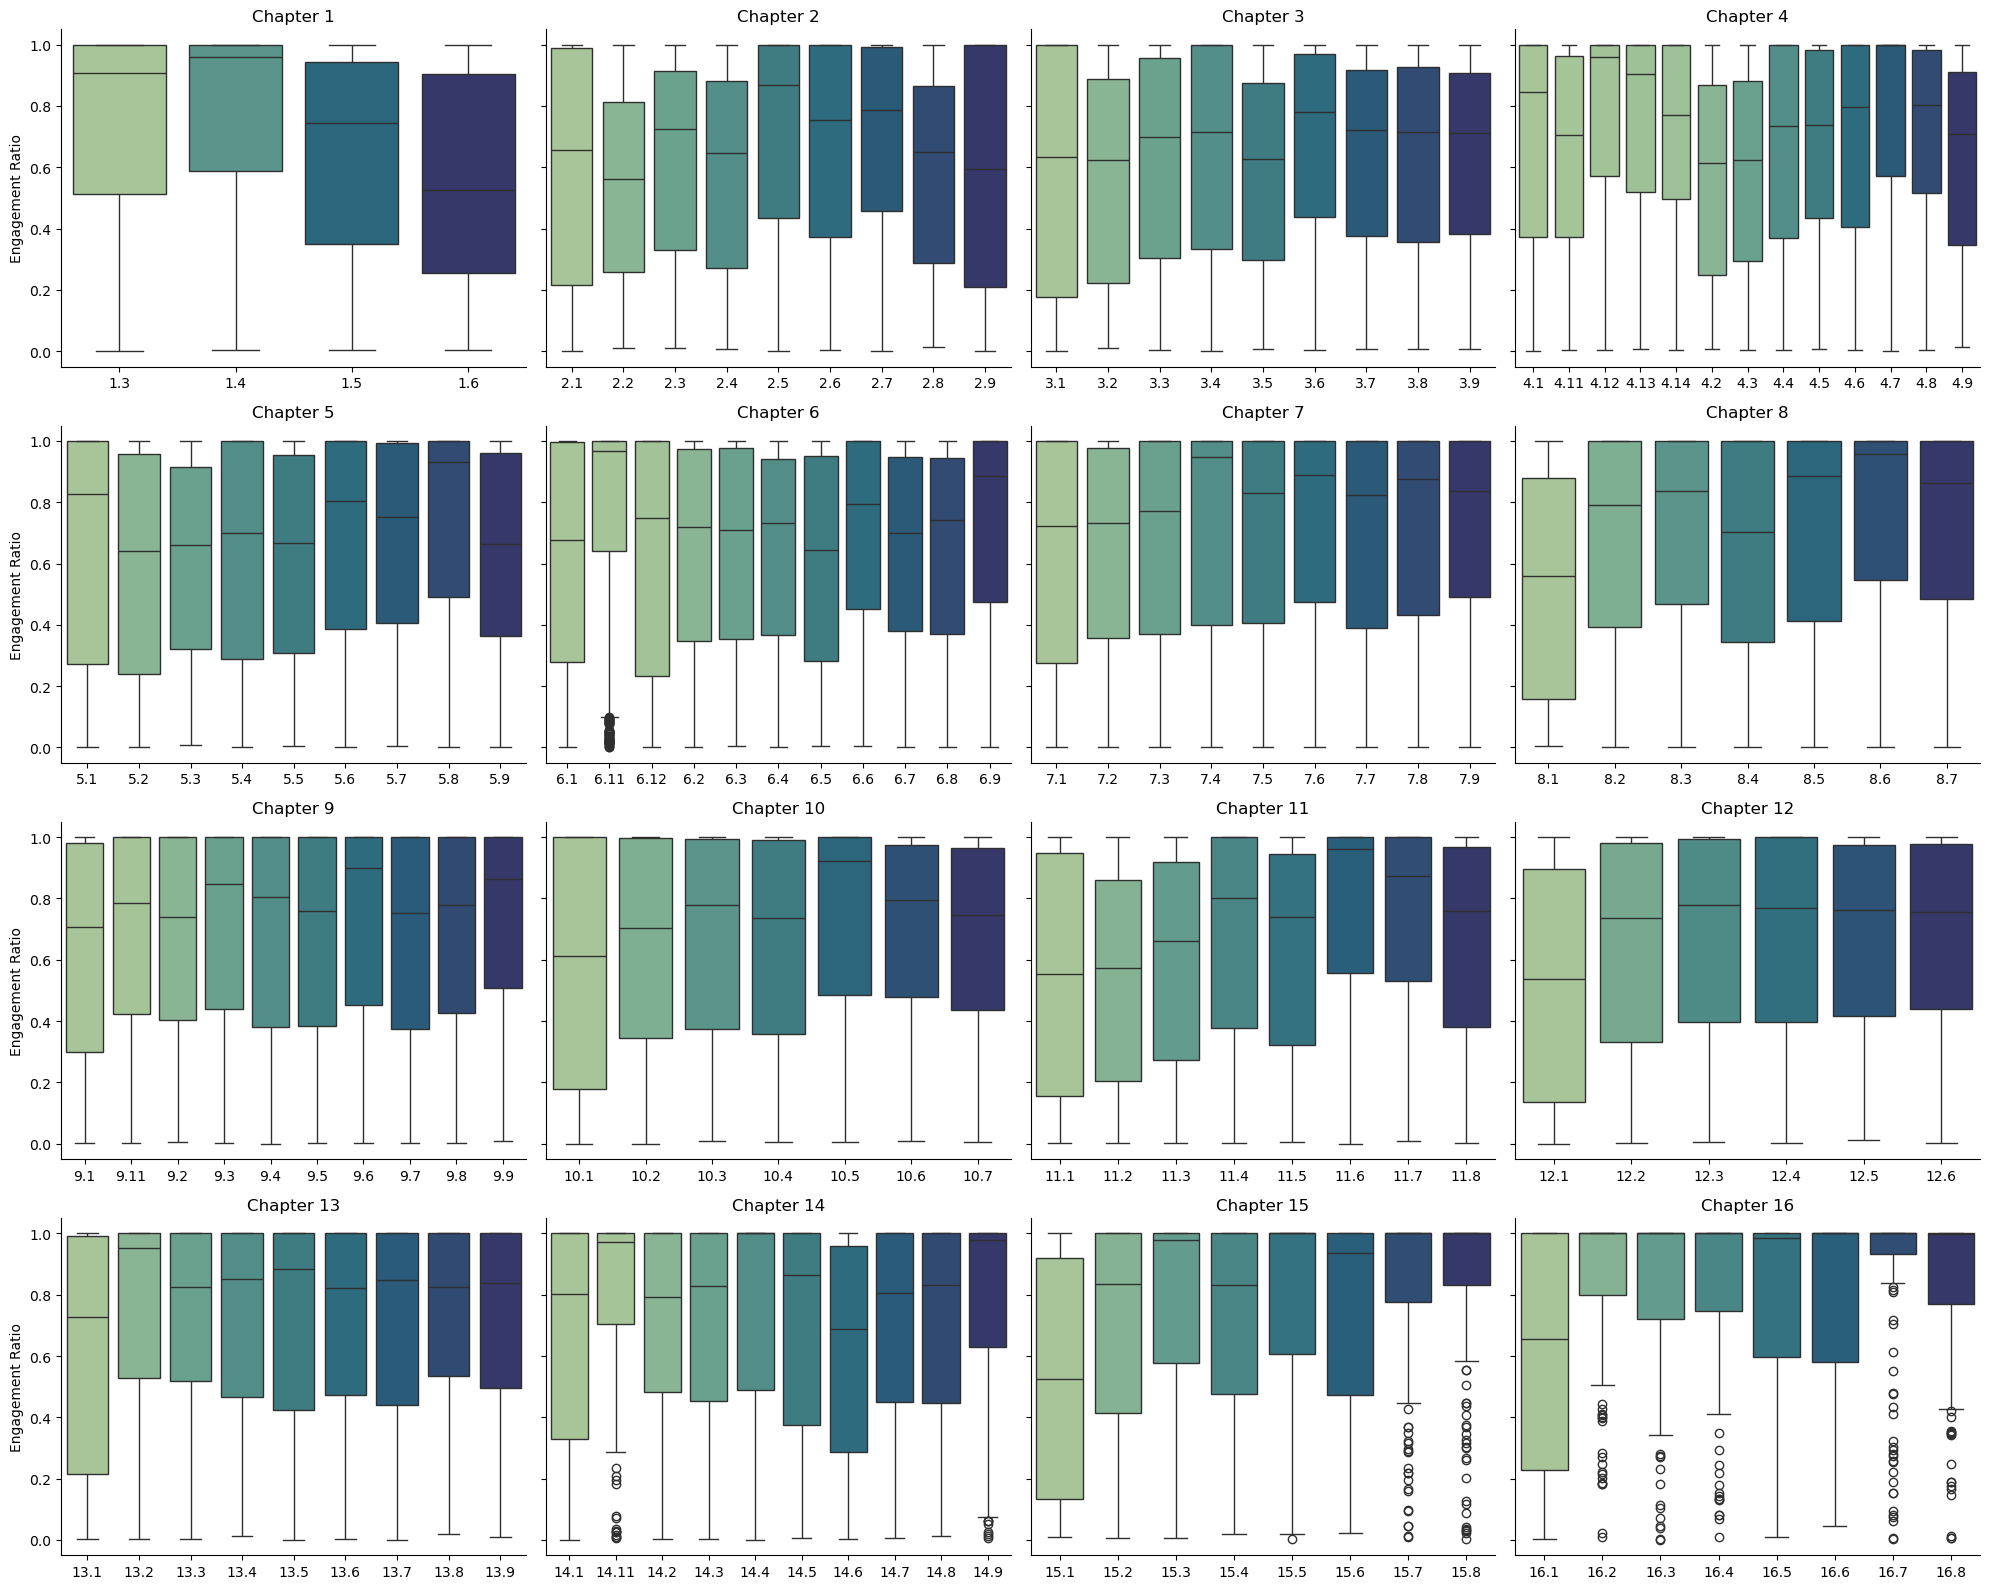

In [133]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16), sharey=True)
axes = axes.flatten()

for i, chapter in enumerate(range(1, 17)):
    ax = axes[i]
    subset = page_views_summary_df[
        (page_views_summary_df['chapter_number'] == chapter) &
        (page_views_summary_df['review_flag'] == False) &
        (page_views_summary_df['was_complete'] == False)
    ]
    
    sns.boxplot(
        data=subset,
        x='chapter_section',
        y='page_engagement_ratio',
        hue='chapter_section',
        legend=False,
        palette='crest',
        ax=ax
    )
    
    ax.set_title(f'Chapter {chapter}')
    ax.set_xlabel('')
    ax.set_ylabel('Engagement Ratio')

# Remove any unused subplots (in case fewer than 16 chapters)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

sns.despine()

plt.tight_layout()

plt.show()

aggregate page_views data into chapter data lose granularity of sections

In [134]:
# chapter dataframe
chapter_engagement_df = (
    page_views_summary_df[page_views_summary_df['review_flag'] == False].groupby(['student_id','chapter_number','was_complete'], as_index=False)
    .agg(
        {
            'engaged': 'sum',
            'page_total_time' : 'sum'
        }
    )
)

chapter_engagement_df.rename(columns={'engaged': 'chapter_engagement_time', 'page_total_time' : 'chapter_total_time'}, inplace=True)
chapter_engagement_df['chapter_engagement_ratio'] = chapter_engagement_df['chapter_engagement_time'] / chapter_engagement_df['chapter_total_time']

In [135]:
chapter_engagement_df['chapter_engaged_log1p'] = np.log1p(chapter_engagement_df['chapter_engagement_time'])
chapter_engagement_df['chapter_total_log'] = np.log(chapter_engagement_df['chapter_total_time'])

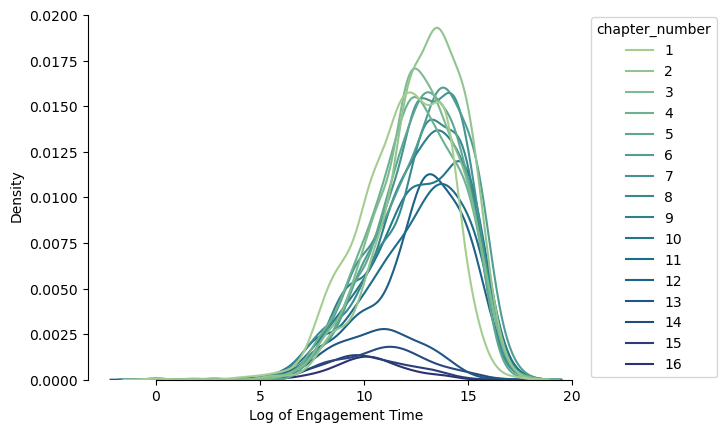

In [138]:
g = sns.kdeplot(
    data=chapter_engagement_df[chapter_engagement_df['was_complete'] == True], 
    x='chapter_engaged_log1p',  
    hue='chapter_number', 
    palette='crest'
)

g.set(xlabel="Log of Engagement Time")

sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
sns.despine(trim=True)

plt.show()

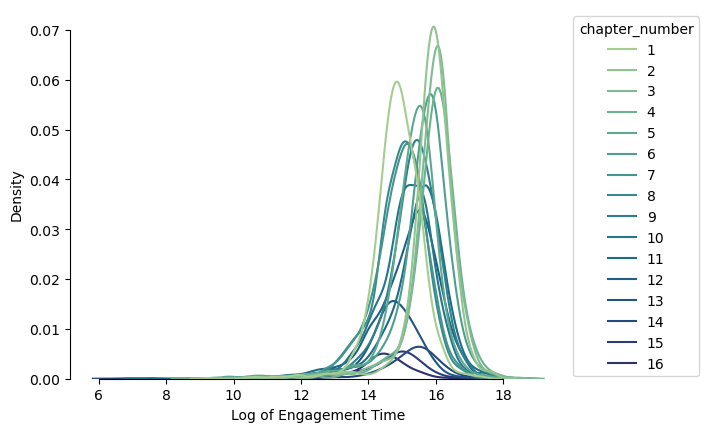

In [139]:
g = sns.kdeplot(
    data=chapter_engagement_df[chapter_engagement_df['was_complete'] == False], 
    x='chapter_engaged_log1p',  
    hue='chapter_number', 
    palette='crest'
)

g.set(xlabel="Log of Engagement Time")

sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
sns.despine(trim=True)

plt.show()

In [140]:
# chapter statistics
chapter_engagement_aggregate_df = (
    chapter_engagement_df.groupby(by=["chapter_number", "was_complete"], as_index=False)
    [["chapter_engagement_time", "chapter_total_time", "chapter_engagement_ratio"]].agg(
        [
            "mean", 
            "sem"
        ]
    )
)

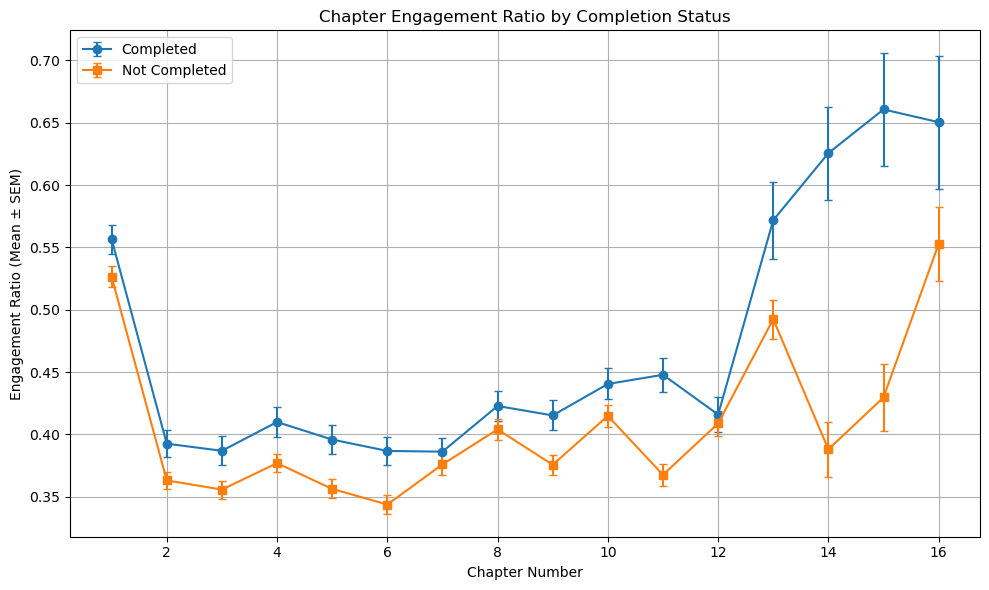

In [141]:
completed = chapter_engagement_aggregate_df[chapter_engagement_aggregate_df["was_complete"] == True]
not_completed = chapter_engagement_aggregate_df[chapter_engagement_aggregate_df["was_complete"] == False]

# Plot
plt.figure(figsize=(10, 6))

# Completed
plt.errorbar(
    completed["chapter_number"],
    completed["chapter_engagement_ratio"]['mean'],
    yerr=completed["chapter_engagement_ratio"]['sem'],
    fmt='-o', label='Completed', capsize=3
)

# Not Completed
plt.errorbar(
    not_completed["chapter_number"],
    not_completed["chapter_engagement_ratio"]['mean'],
    yerr=not_completed["chapter_engagement_ratio"]["sem"],
    fmt='-s', label='Not Completed', capsize=3
)

plt.xlabel("Chapter Number")
plt.ylabel("Engagement Ratio (Mean ± SEM)")
plt.title("Chapter Engagement Ratio by Completion Status")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

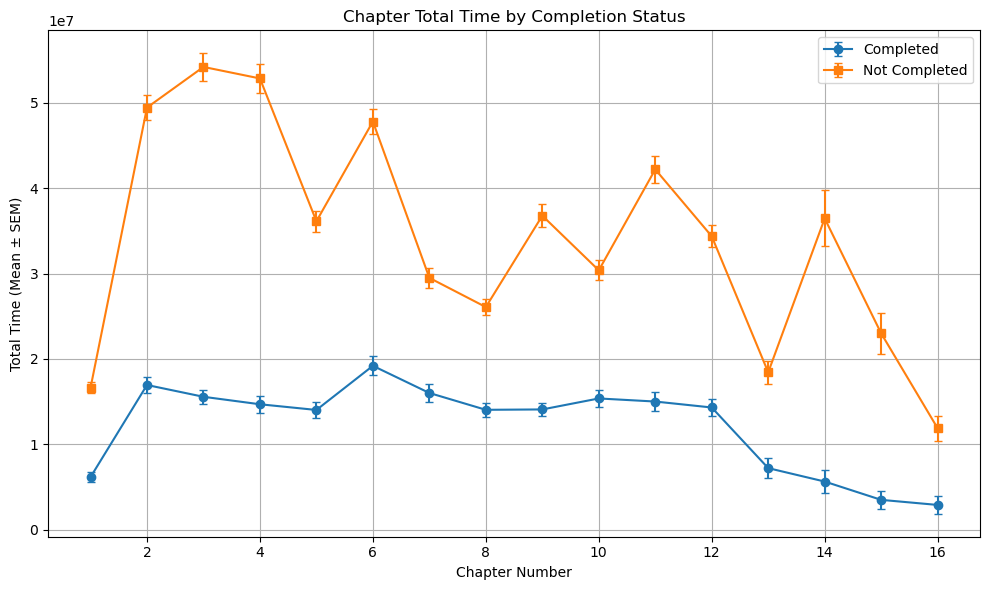

In [142]:
# Plot
plt.figure(figsize=(10, 6))

# Completed
plt.errorbar(
    completed["chapter_number"],
    completed["chapter_total_time"]['mean'],
    yerr=completed["chapter_total_time"]['sem'],
    fmt='-o', label='Completed', capsize=3
)

# Not Completed
plt.errorbar(
    not_completed["chapter_number"],
    not_completed["chapter_total_time"]['mean'],
    yerr=not_completed["chapter_total_time"]["sem"],
    fmt='-s', label='Not Completed', capsize=3
)

plt.xlabel("Chapter Number")
plt.ylabel("Total Time (Mean ± SEM)")
plt.title("Chapter Total Time by Completion Status")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

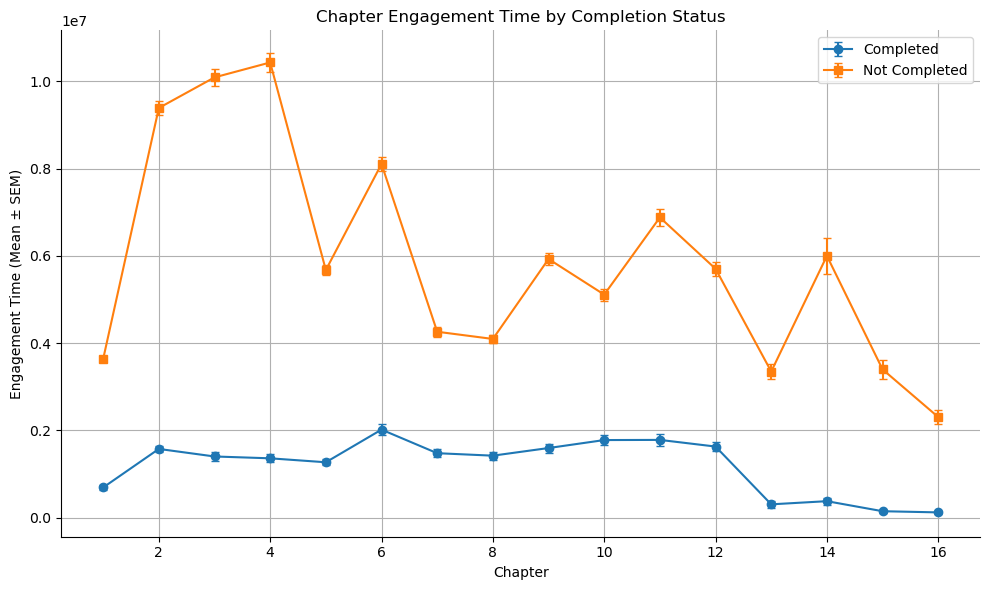

In [144]:
# Plot
plt.figure(figsize=(10, 6))

# Completed
plt.errorbar(
    completed["chapter_number"],
    completed["chapter_engagement_time"]['mean'],
    yerr=completed["chapter_engagement_time"]['sem'],
    fmt='-o', label='Completed', capsize=3
)

# Not Completed
plt.errorbar(
    not_completed["chapter_number"],
    not_completed["chapter_engagement_time"]['mean'],
    yerr=not_completed["chapter_engagement_time"]["sem"],
    fmt='-s', label='Not Completed', capsize=3
)

sns.despine()
plt.xlabel("Chapter")
plt.ylabel("Engagement Time (Mean ± SEM)")
plt.title("Chapter Engagement Time by Completion Status")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

new metric look at ratios of engagement with sections in a chapter

In [145]:
page_views_summary_df = page_views_summary_df[page_views_summary_df['review_flag'] == False].merge(right=chapter_engagement_df[['student_id','chapter_number','was_complete','chapter_engagement_time']], on=['student_id', 'chapter_number','was_complete'], how='left')

In [146]:
page_views_summary_df['relative_page_engagement'] = page_views_summary_df['engaged'] / page_views_summary_df['chapter_engagement_time']
page_views_summary_df['relative_page_engagement_log'] = np.log1p(page_views_summary_df['relative_page_engagement']) #log(1+x)

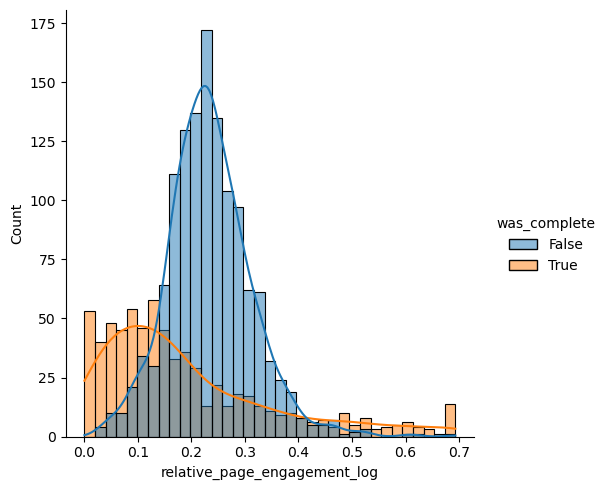

In [156]:
sns.displot(data=page_views_summary_df[page_views_summary_df['chapter_section'] == 2.8], x='relative_page_engagement_log', kde=True, hue='was_complete')
plt.show()

In [157]:
checkpoints_summary_df = (
    checkpoints_df.groupby(['student_id', 'chapter_number', 'EOC'], as_index=False)
    .agg(
        {
            'EOC' : 'mean'
        }
    )
)

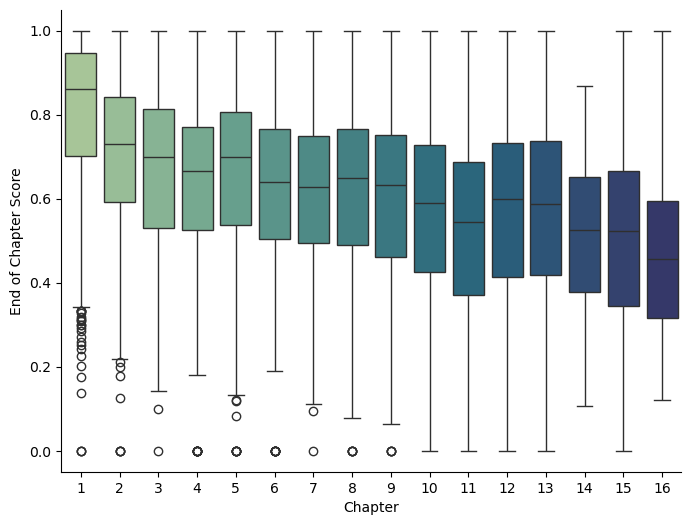

In [158]:
plt.figure(figsize=(8,6))

sns.boxplot(data=checkpoints_summary_df, 
            x='chapter_number', 
            y='EOC',
            hue='chapter_number',
            legend=False,
            palette="crest")

sns.despine()
plt.ylabel("End of Chapter Score")
plt.xlabel("Chapter")

plt.show()

In [159]:
checkpoints_aggregate_df = checkpoints_summary_df.groupby(by=["chapter_number"], as_index=False)["EOC"].agg(["mean","sem"])

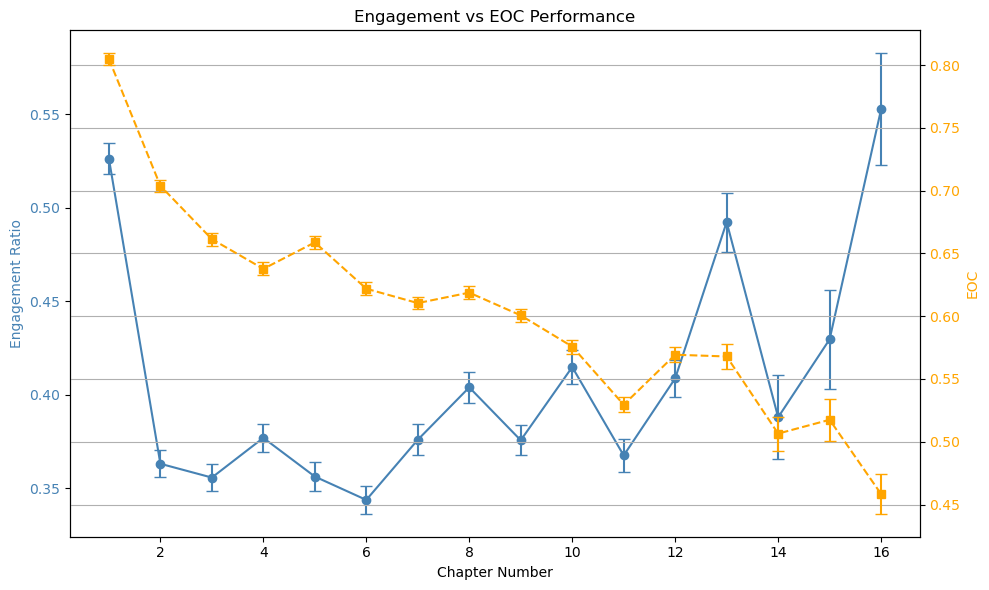

In [160]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.errorbar(
    x=not_completed["chapter_number"],
    y=not_completed['chapter_engagement_ratio']["mean"],
    yerr=not_completed['chapter_engagement_ratio']["sem"],
    fmt='o-', capsize=4, label="Engagement", color="steelblue"
)
ax1.set_ylabel("Engagement Ratio", color="steelblue")
ax1.tick_params(axis='y', labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.errorbar(
    x=checkpoints_aggregate_df["chapter_number"],
    y=checkpoints_aggregate_df["mean"],
    yerr=checkpoints_aggregate_df["sem"],
    fmt='s--', capsize=4, label="Performance", color="orange"
)
ax2.set_ylabel("EOC", color="orange")
ax2.tick_params(axis='y', labelcolor="orange")

plt.title("Engagement vs EOC Performance")
ax1.set_xlabel("Chapter Number")
fig.tight_layout()
plt.grid(True)
plt.show()


In [181]:
# dictionary containing chapter data
chapter_dfs = {
    chapter: page_views_summary_df[
        (page_views_summary_df['chapter_number'] == chapter) &
        (page_views_summary_df['was_complete'] == False) &
        (page_views_summary_df['review_flag'] == False)].copy() 
    for chapter in page_views_summary_df['chapter_number'].unique()
}

# dictionary for end of chapter score
eoc_dfs = {
}

In [185]:
for i in range(1,17):
    # pivot dataframe to get sections as columns, engagements in rows
    chapter_dfs[i] = chapter_dfs[i].pivot_table(
        index=['student_id', 'chapter_number'],
        columns='chapter_section',
        values='relative_page_engagement',
        aggfunc='mean'  # If there are duplicates
    )
    
    chapter_dfs[i] = chapter_dfs[i].reset_index()

    # merge with end of chapter scores so order is consistent
    chapter_dfs[i] = chapter_dfs[i].merge(
        checkpoints_summary_df,
        on=['student_id', 'chapter_number'],
        how='left'
    )

    # seperate dataframes
    eoc_dfs[i] = chapter_dfs[i][['student_id', 'chapter_number', 'EOC']]
    chapter_dfs[i].drop(columns=['student_id', 'chapter_number', 'EOC'], inplace=True)
    chapter_dfs[i].fillna(0, inplace=True)

In [186]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [187]:
dim_red = {}

for chapter, df in chapter_dfs.items():

    # Standardize features
    X_scaled = StandardScaler().fit_transform(df)

    # Initialize and fit PCA
    pca = PCA(n_components=2)  # or any number you want
    principal_components = pca.fit_transform(X_scaled)

    # Store results
    dim_red[chapter] = {
        'pca': pca,
        'components': pd.DataFrame(principal_components, columns=['PC1','PC2'])
    }

    dim_red[chapter]['components'] = dim_red[chapter]['components'].merge(eoc_dfs[chapter], left_index=True, right_index=True)

In [188]:
loadings = {
    chapter : pd.DataFrame(dim_red[chapter]['pca'].components_.T, columns=['PC1', 'PC2'], index=chapter_dfs[chapter].columns.tolist())
    for chapter in dim_red
}

In [189]:
import numpy as np

In [190]:
for chapter in loadings:
    loadings[chapter]['mag'] = np.linalg.norm(loadings[chapter], axis=1)

In [191]:
for chapter in dim_red:
    print(f"{chapter} Variance: {dim_red[chapter]['pca'].explained_variance_ratio_}")
    print(f"{chapter} Singular values: {dim_red[chapter]['pca'].singular_values_} \n")

1 Variance: [0.45800987 0.28547865]
1 Singular values: [51.84208663 40.92906911] 

2 Variance: [0.20074872 0.14988289]
2 Singular values: [49.89674988 43.11435475] 

3 Variance: [0.21986316 0.16291613]
3 Singular values: [51.37778747 44.22636207] 

4 Variance: [0.17903468 0.11239988]
4 Singular values: [54.47476368 43.1628086 ] 

5 Variance: [0.17519355 0.15716318]
5 Singular values: [45.11733427 42.73264585] 

6 Variance: [0.19471896 0.13211724]
6 Singular values: [53.51384573 44.08002049] 

7 Variance: [0.19639983 0.17267168]
7 Singular values: [48.8674276 45.8204642] 

8 Variance: [0.29600944 0.21041131]
8 Singular values: [52.77174282 44.49212929] 

9 Variance: [0.16909859 0.14482679]
9 Singular values: [46.74134934 43.25693174] 

10 Variance: [0.23750365 0.19090744]
10 Singular values: [44.4418763  39.84452642] 

11 Variance: [0.21911932 0.21816141]
11 Singular values: [43.36957735 43.27467567] 

12 Variance: [0.27768573 0.21622718]
12 Singular values: [41.80614805 36.890837  ] 



In [212]:
def loading_plot(
    coeff, labels, scale=1, colors=None, visible=None, ax=plt, arrow_size=0.5
):
    for i, label in enumerate(labels):
        if visible is None or visible[i]:
            ax.arrow(
                0,
                0,
                coeff[i, 0] * scale,
                coeff[i, 1] * scale,
                head_width=arrow_size * scale,
                head_length=arrow_size * scale,
                color="#000" if colors is None else colors[i],
            )
            ax.text(
                coeff[i, 0] * 1.15 * scale,
                coeff[i, 1] * 1.15 * scale,
                label,
                color='red' if colors is None else colors[i],
                ha="center",
                va="center",
                fontsize=12
            )

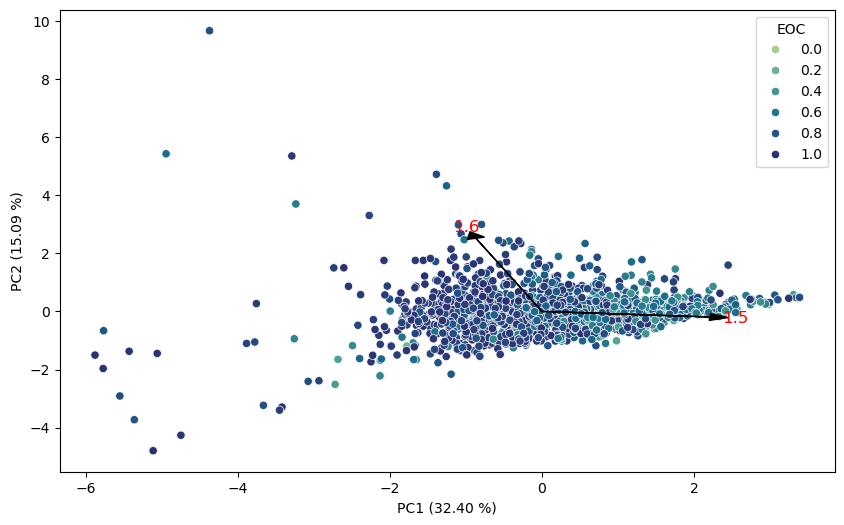

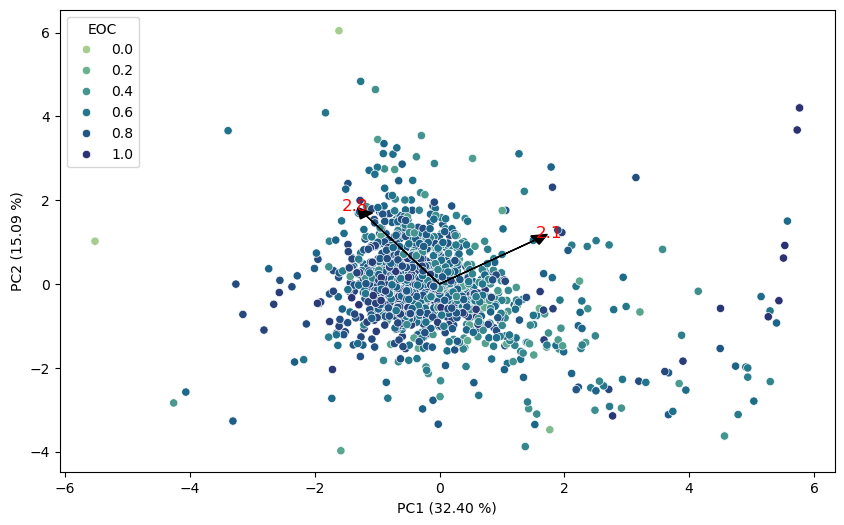

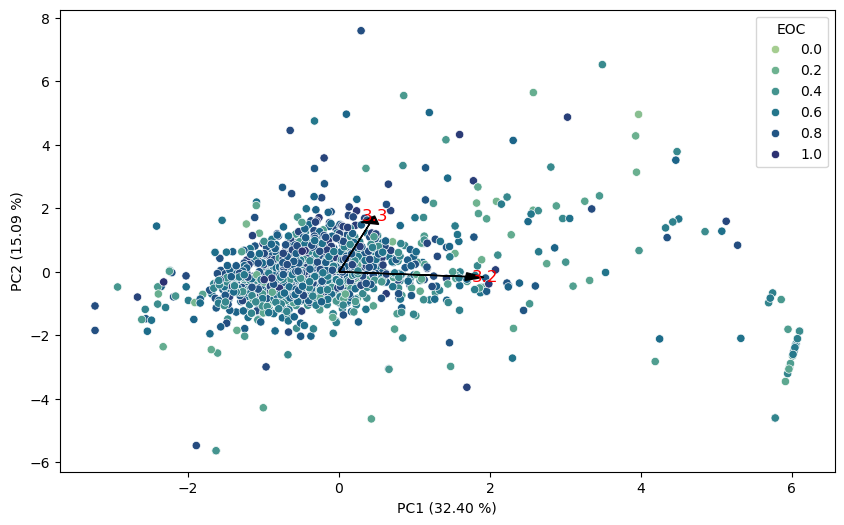

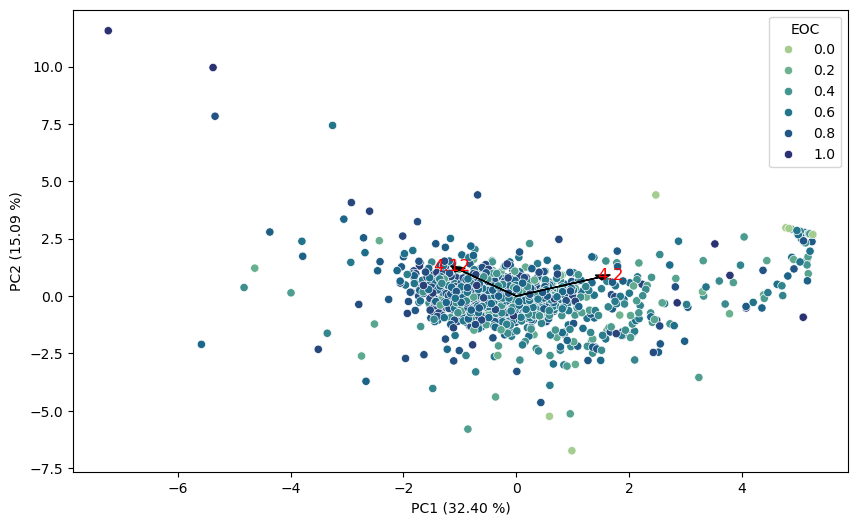

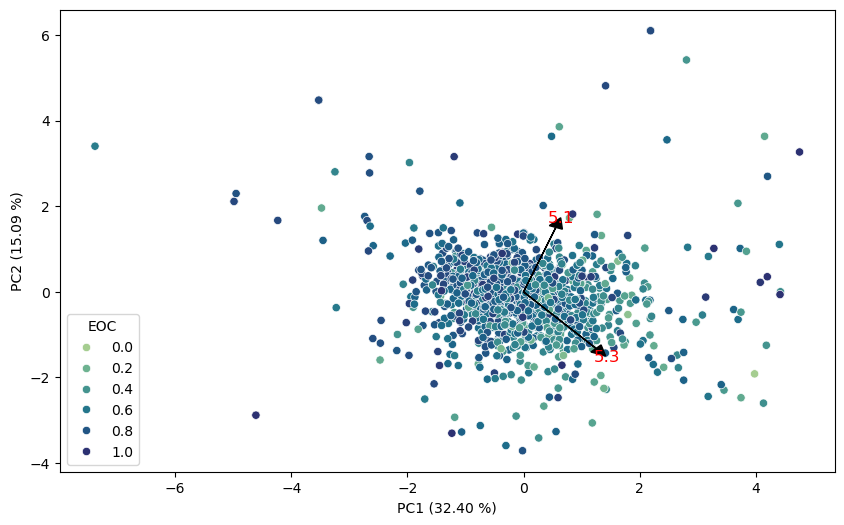

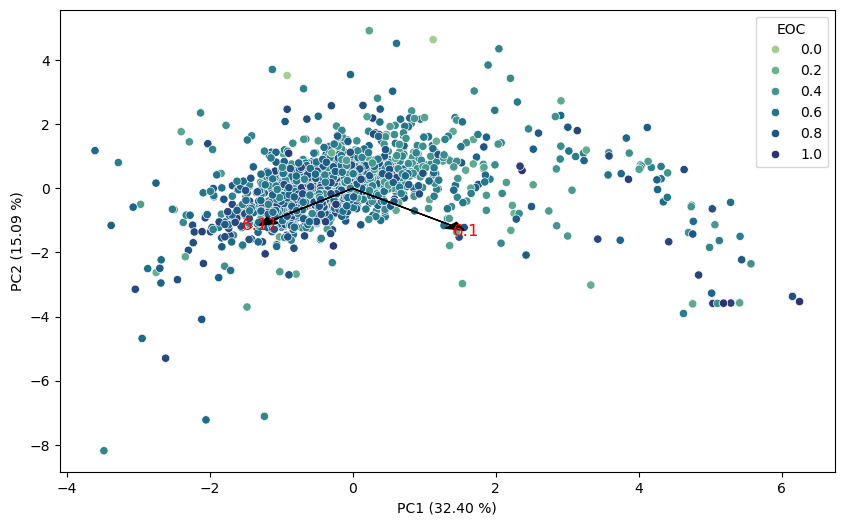

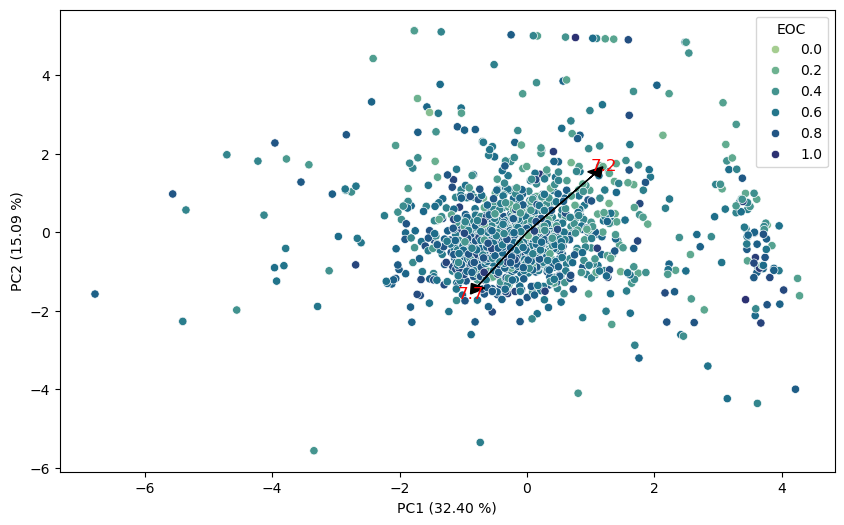

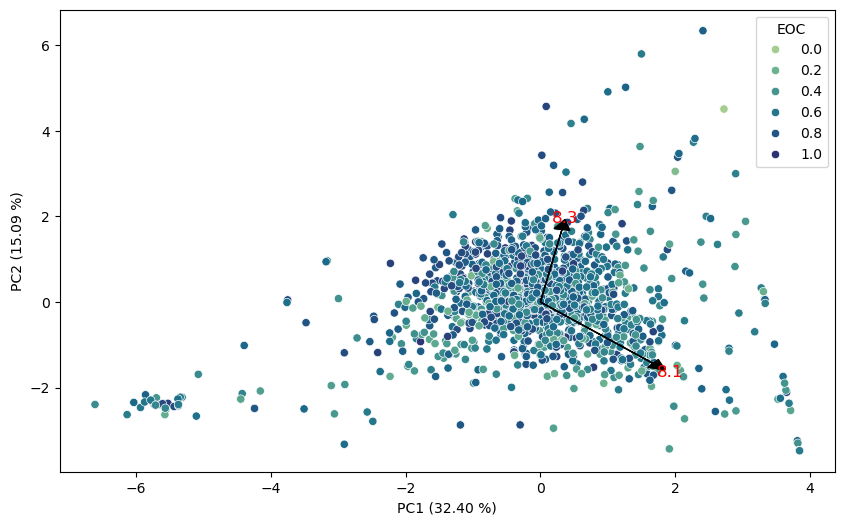

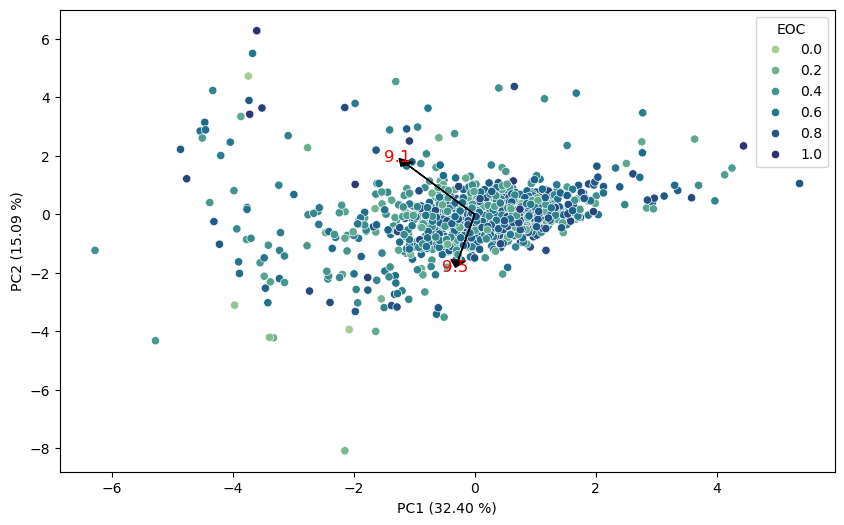

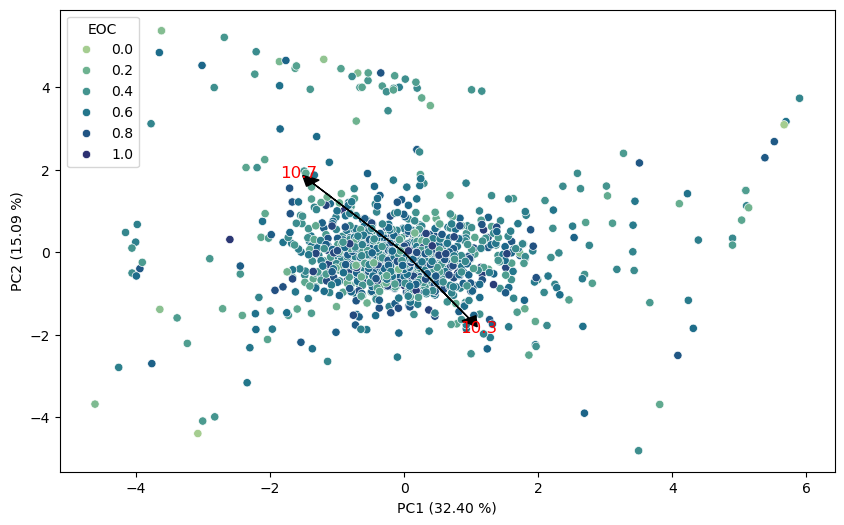

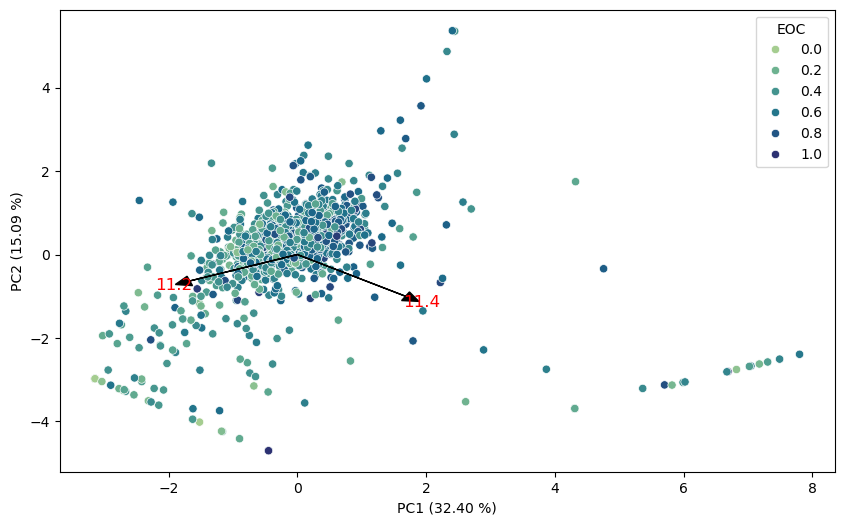

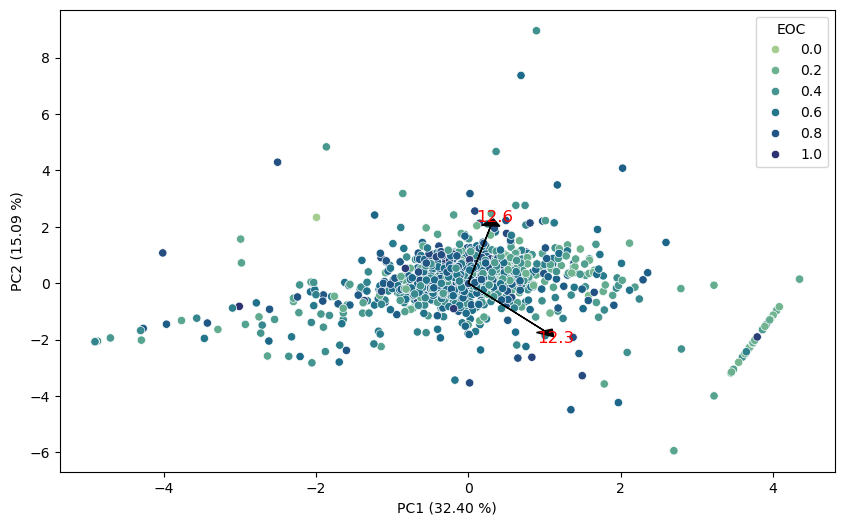

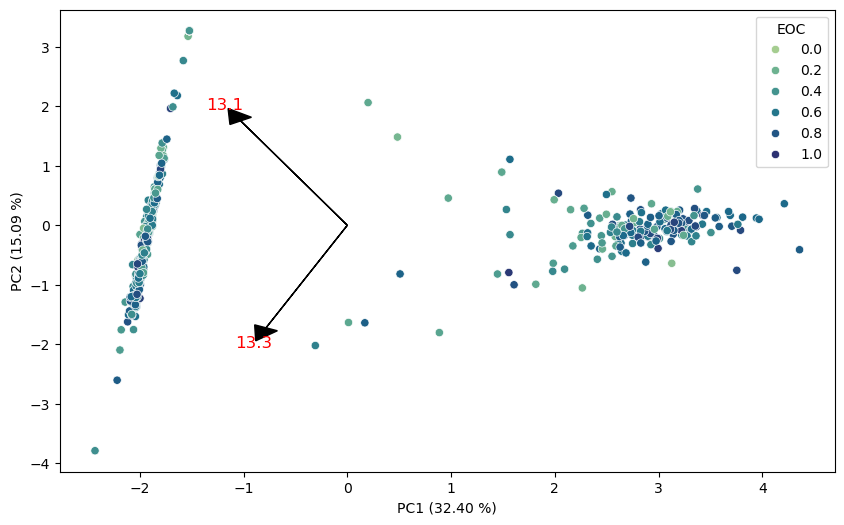

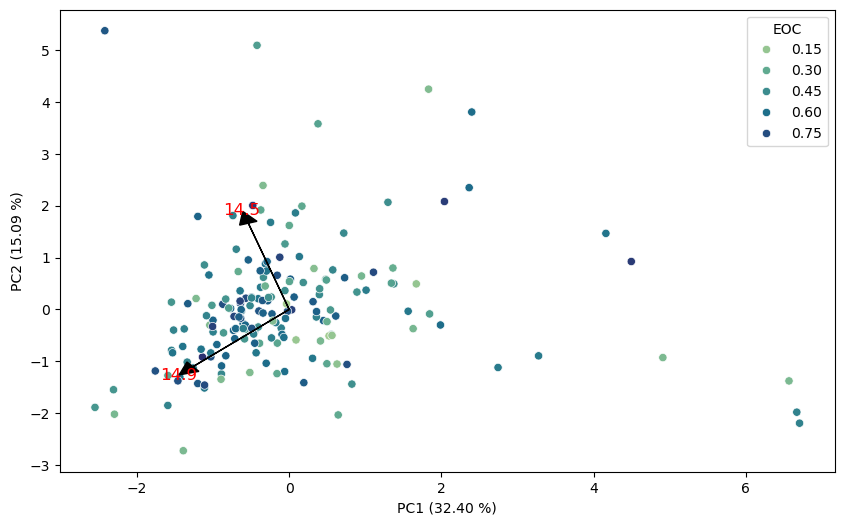

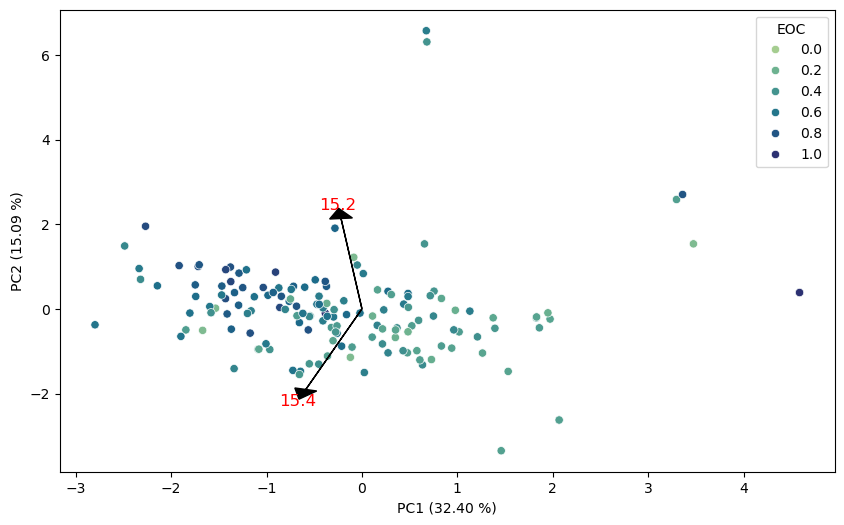

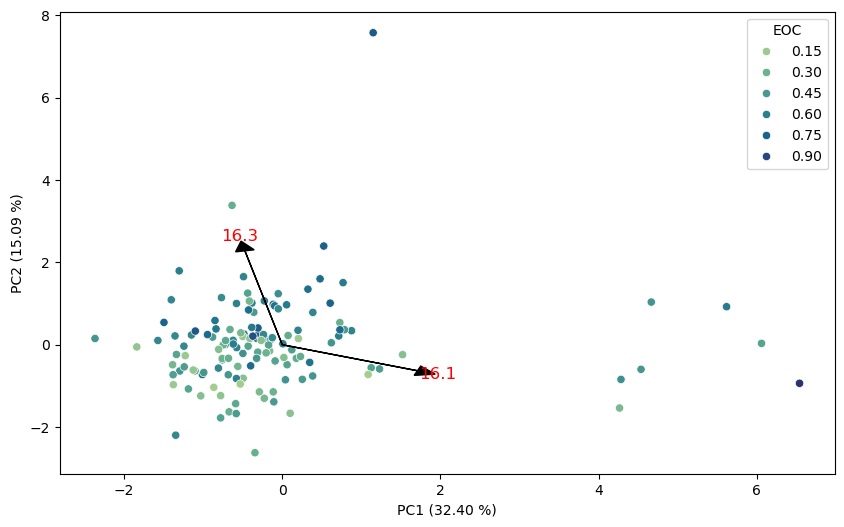

In [220]:
for i in range(1,17):
    plt.figure(figsize=(10,6))

    g = sns.scatterplot(data=dim_red[i]['components'], x='PC1', y='PC2', hue='EOC', palette='crest')

    # Get indices of top 3 loadings based on magnitude
    top_2_indices = loadings[i].nlargest(2, 'mag').index

    # Add loadings
    loading_plot(loadings[i].loc[top_2_indices][["PC1", "PC2"]].values, loadings[i].loc[top_2_indices].index, scale=3, arrow_size=0.08)

    # Add variance explained by the
    g.set_xlabel(f"PC1 ({dim_red[chapter]['pca'].explained_variance_ratio_[0]*100:.2f} %)")
    g.set_ylabel(f"PC2 ({dim_red[chapter]['pca'].explained_variance_ratio_[1]*100:.2f} %)")

    plt.savefig(f"Figures/chapter-figures/{i}.png", dpi=300)
    plt.show()

In [39]:
dim_red[2]['components']

,PC1,PC2,student_id,chapter_number,EOC
0,-2.232979,0.380451,001824fb-a2fd-431d-aef6-7a1250d97a62,2,0.839080
1,-1.118870,-0.074551,0096491a-77bf-4e79-b906-fc7a8e5e57a6,2,0.580952
2,-0.910080,-0.140297,00a53a52-aa0e-4ddc-afa8-2c50c21dfd03,2,0.420765
3,2.030216,-0.270630,00fe5bb2-6b64-4a36-a706-eac4dc124ea7,2,0.905882
4,1.211879,-2.586865,016e2fcf-0cc2-42ad-844d-e1057b5081cc,2,0.772727
...,...,...,...,...,...
1376,0.801116,0.768337,fe9b193e-d82e-4612-97de-051cb7d87c2c,2,0.752381
1377,1.875836,0.577154,fecc783d-1cd1-4940-aa16-695c4652a536,2,0.650485
1378,-0.057710,0.292938,fecf18d0-a58a-4d11-a353-ea73fbfa6860,2,0.363636
1379,-1.838663,1.239255,ff55bab4-812b-405b-9856-8bedf9fb11f9,2,0.800000


In [40]:
outlier_index = dim_red[2]['components'].apply(
    lambda row: np.linalg.norm([row['PC1'], row['PC2']]), axis=1
).idxmax()


In [41]:
dim_red[2]['components'].iloc[outlier_index]

PC1                                          -5.986975
PC2                                           0.139421
student_id        e659a90c-eb0d-4b53-8672-40c622af6176
chapter_number                                       2
EOC                                                NaN
Name: 1243, dtype: object

In [42]:
chapter_dfs[2].iloc[outlier_index]

2.1     0.001848
2.11    0.000000
2.2     0.000000
2.3     0.000000
2.4     0.000000
2.5     0.000000
2.6     0.000000
2.7     0.000000
2.8     0.000000
2.9     0.000000
Name: 1243, dtype: float64

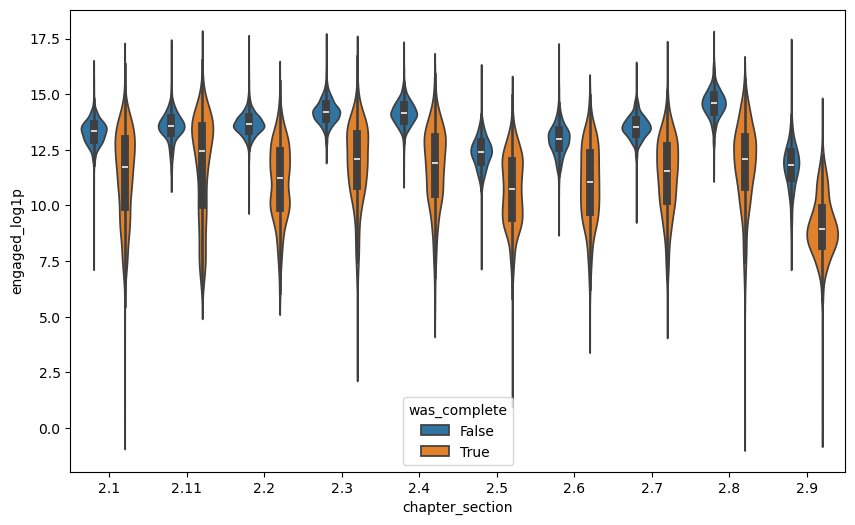

In [43]:
plt.figure(figsize=(10,6))
sns.violinplot(data=page_views_summary_df[page_views_summary_df['chapter_number'] == 2], x='chapter_section', y='engaged_log1p', hue='was_complete')
plt.show()

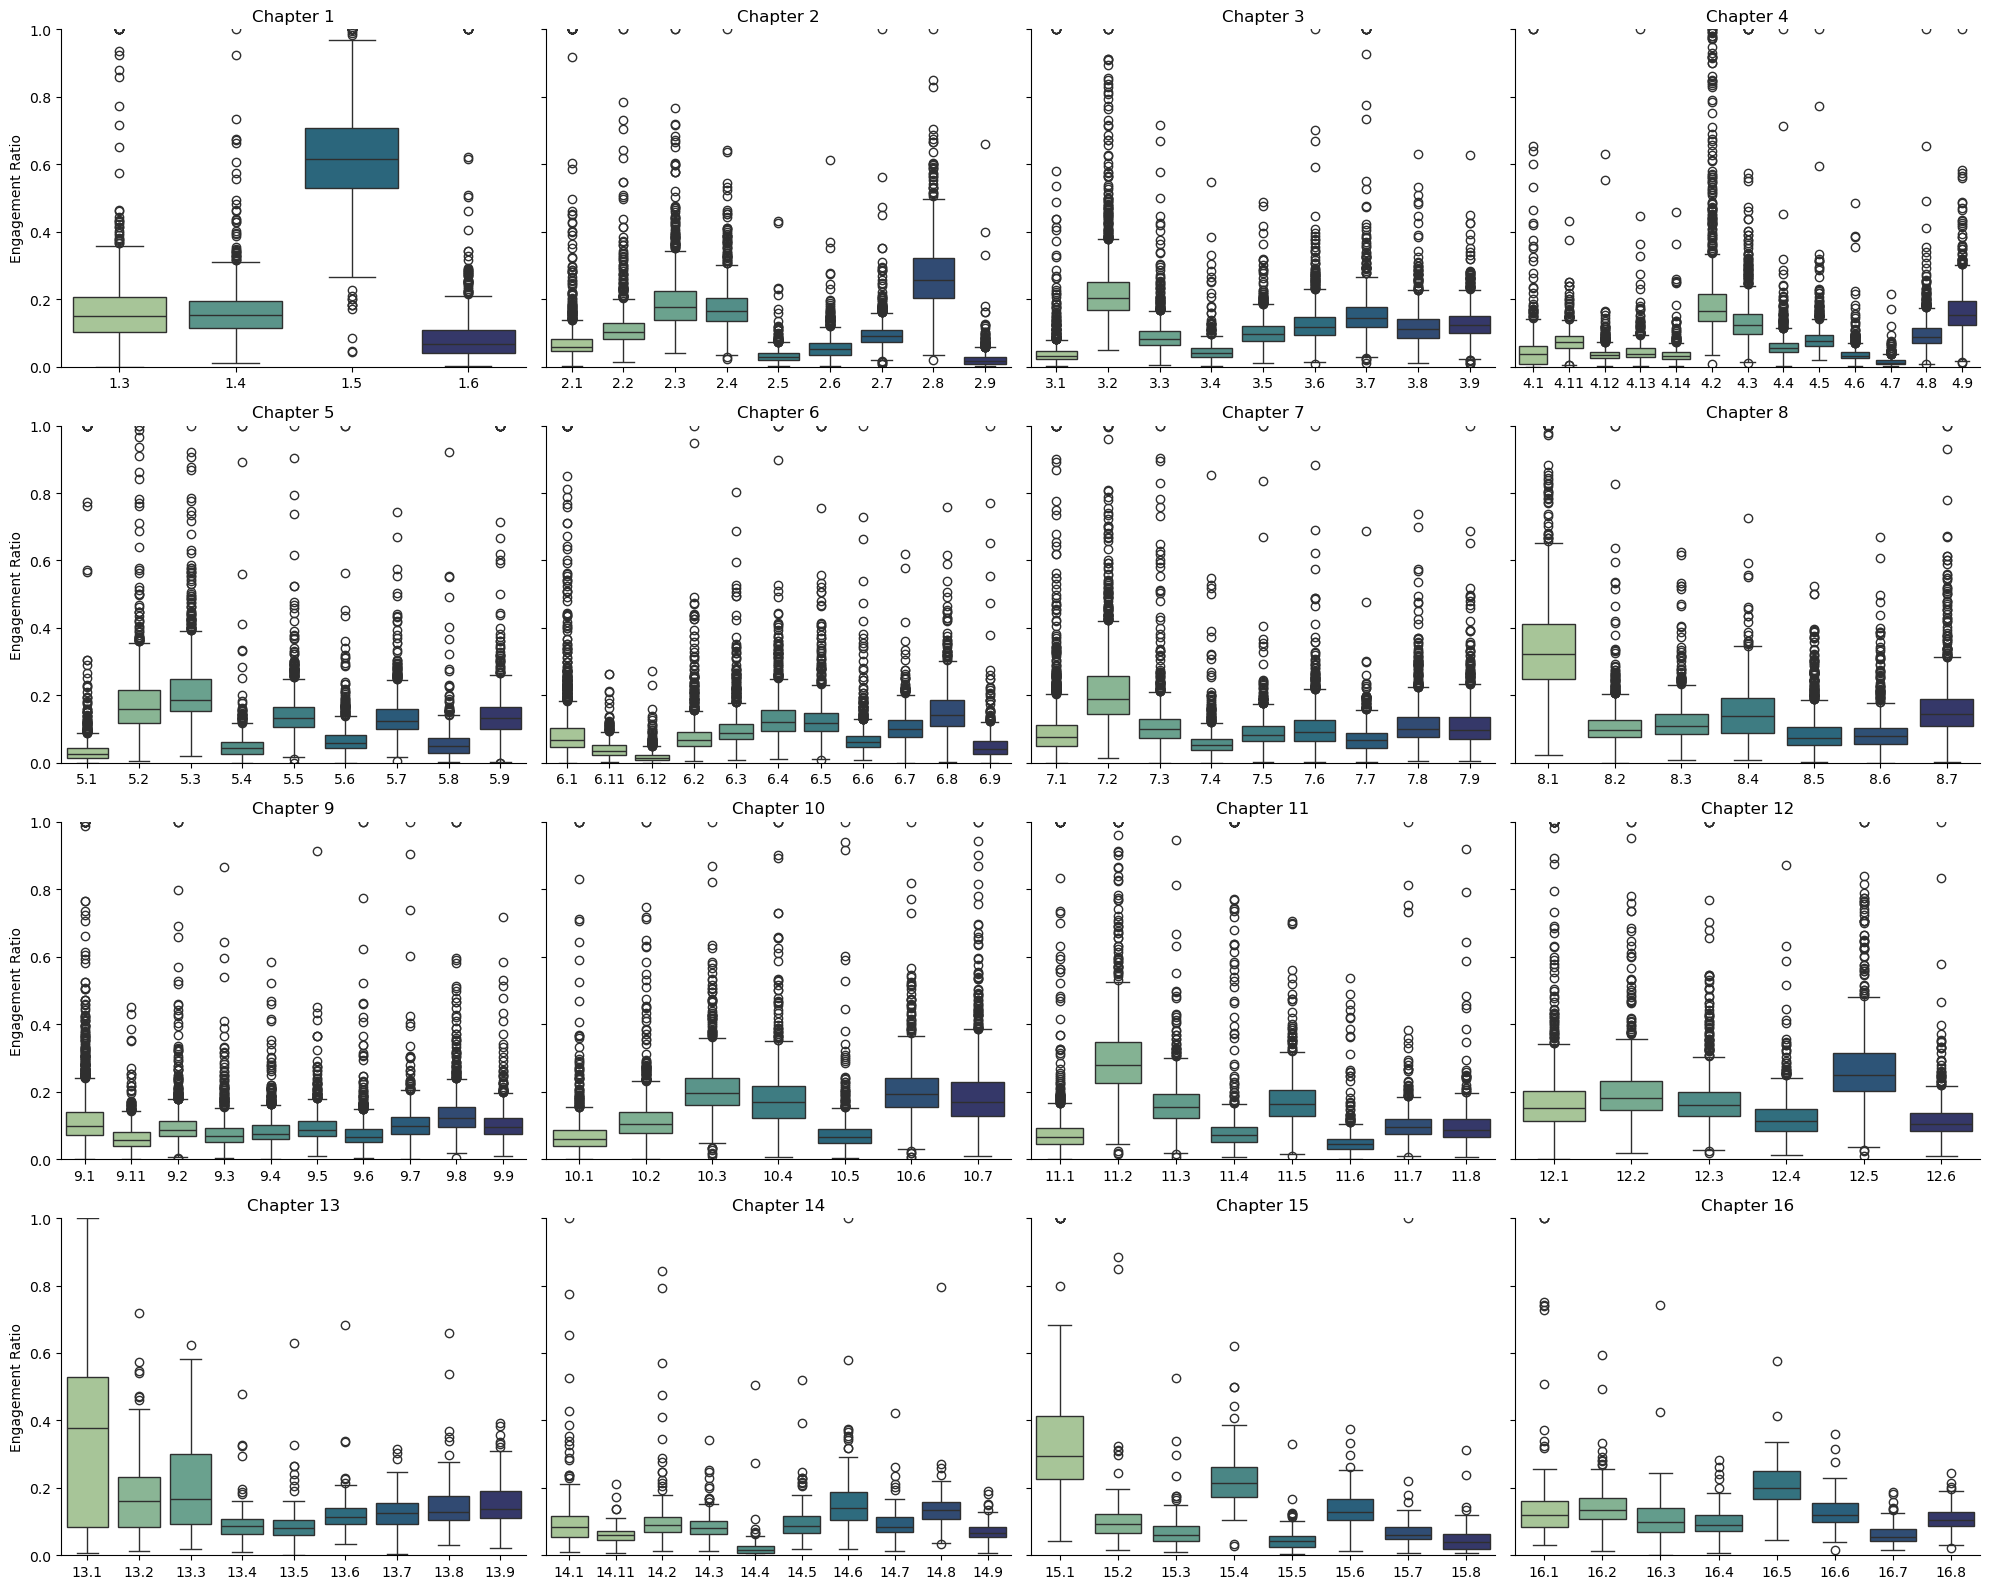

In [152]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16), sharey=True)
axes = axes.flatten()

for i, chapter in enumerate(range(1, 17)):
    ax = axes[i]
    subset = page_views_summary_df[
        (page_views_summary_df['chapter_number'] == chapter) &
        (page_views_summary_df['review_flag'] == False) &
        (page_views_summary_df['was_complete'] == False)
    ]
    
    sns.boxplot(
        data=subset,
        x='chapter_section',
        y='relative_page_engagement',
        hue='chapter_section',
        legend=False,
        palette='crest',
        ax=ax
    )

    plt.ylim(0,1)
    
    ax.set_title(f'Chapter {chapter}')
    ax.set_xlabel('')
    ax.set_ylabel('Engagement Ratio')

    # ax.tick_params(axis='x', rotation=45)

# Remove any unused subplots (in case fewer than 16 chapters)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

sns.despine()

plt.tight_layout()

plt.show()